# Linear Regression Analysis (R)

This notebook loads salary data, visualizes the relationship between years of experience and salary, fits a linear regression model, overlays the regression line on a scatter plot, and evaluates model performance.

In [1]:
library(ggplot2)

In [2]:
df <- read.csv("regression_data.csv", stringsAsFactors = FALSE)

print("First rows:")
print(head(df))
print(paste("\nDimensions:", nrow(df), "rows,", ncol(df), "columns"))
print("\nStructure:")
str(df)

[1] "First rows:"


  YearsExperience Salary
1             1.1  39343
2             1.3  46205
3             1.5  37731
4             2.0  43525
5             2.2  39891
6             2.9  56642


[1] "\nDimensions: 10 rows, 2 columns"


[1] "\nStructure:"


'data.frame':	10 obs. of  2 variables:
 $ YearsExperience: num  1.1 1.3 1.5 2 2.2 2.9 3 3.2 3.7 4
 $ Salary         : num  39343 46205 37731 43525 39891 ...


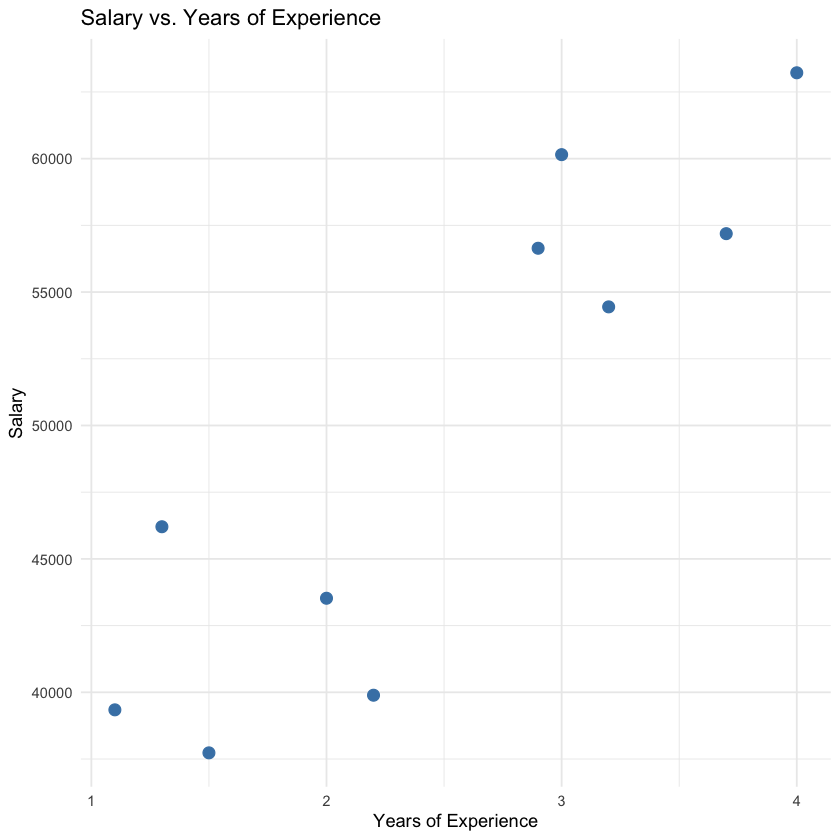

In [3]:
ggplot(df, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "steelblue", size = 3) +
  labs(
    x = "Years of Experience",
    y = "Salary",
    title = "Salary vs. Years of Experience"
  ) +
  theme_minimal()

In [4]:
model <- lm(Salary ~ YearsExperience, data = df)

intercept <- coef(model)[1]
slope <- coef(model)[2]

cat(sprintf("Intercept: %.2f\n", intercept))
cat(sprintf("Slope: %.2f\n", slope))
cat(sprintf("Regression equation: Salary = %.2f + %.2f * YearsExperience\n", intercept, slope))

Intercept: 29203.52


Slope: 8285.29


Regression equation: Salary = 29203.52 + 8285.29 * YearsExperience


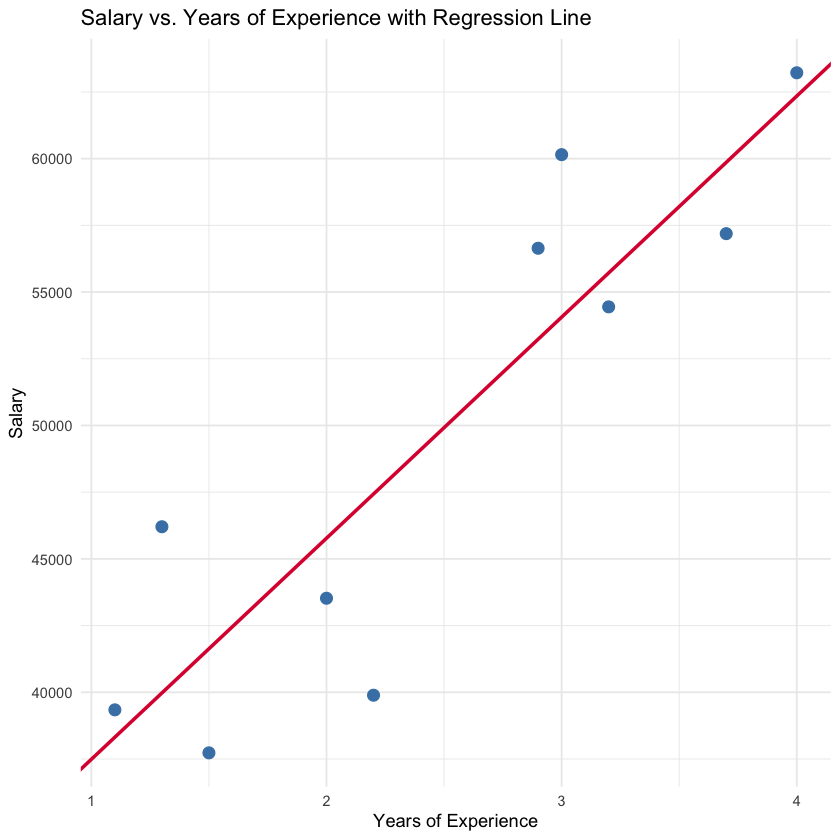

In [5]:
ggplot(df, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "steelblue", size = 3) +
  geom_abline(intercept = intercept, slope = slope, color = "#DC143C", linewidth = 1) +
  labs(
    x = "Years of Experience",
    y = "Salary",
    title = "Salary vs. Years of Experience with Regression Line"
  ) +
  theme_minimal()

In [6]:
y_pred <- predict(model, df)
y <- df$Salary
residuals <- y - y_pred
n <- length(y)

r2 <- summary(model)$r.squared
rmse <- sqrt(mean((y - y_pred)^2))
mae <- mean(abs(y - y_pred))
residual_se <- sqrt(sum(residuals^2) / (n - 2))

cat("Model Performance\n")
cat("-----------------\n")
cat(sprintf("R-squared:              %.4f\n", r2))
cat(sprintf("RMSE:                   %.2f\n", rmse))
cat(sprintf("MAE:                    %.2f\n", mae))
cat(sprintf("Residual Std. Error:    %.2f\n", residual_se))

Model Performance


-----------------


R-squared:              0.7852


RMSE:                   4186.15


MAE:                    3526.26


Residual Std. Error:    4680.26


## Interpretation

The positive slope indicates that salary tends to increase with years of experience. R-squared shows the proportion of variance in salary explained by the linear model, while RMSE and MAE summarize typical prediction error in salary units.